In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, HDBSCAN, KMeans
from kmedoids import KMedoids
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, benchmark_functional_groups, evaluate_hdbscan_grid

projection_method = "UMAP"

In [3]:
qm9 = QM9Dataset(limit=5000, descriptors=["onehot"])
df = qm9.load()
X = np.array(df['selfies_onehot'].to_list())

2026-05-12 16:56:44.708 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-12 16:56:45.213 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000, sampling on columns=['num_atoms', 'gap'].
2026-05-12 16:56:45.214 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-12 16:56:45.214 | INFO     | src.features:compute_selfies_onehot:284 - Computing One-Hot Encodings...
2026-05-12 16:56:45.561 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['selfies_onehot']


In [ ]:
ls_selfies = np.array(df['selfies_onehot'].to_list())
ls_selfies[0]

array([0, 0, 0, ..., 0, 0, 1], shape=(1008,))

In [4]:
dist_type = "tanimoto"
dist_matrix = qm9.get_distance_matrix(
    descriptor="onehot",
    dist_type=dist_type,
)

2026-05-12 16:56:45.735 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for onehot using jaccard distance.


# Determining the best number of clusters for each clustering method

In [ ]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    dataset_name="qm9",
)

NameError: name 'dist_matrix' is not defined

# Hiercical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_41122/3187935628.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


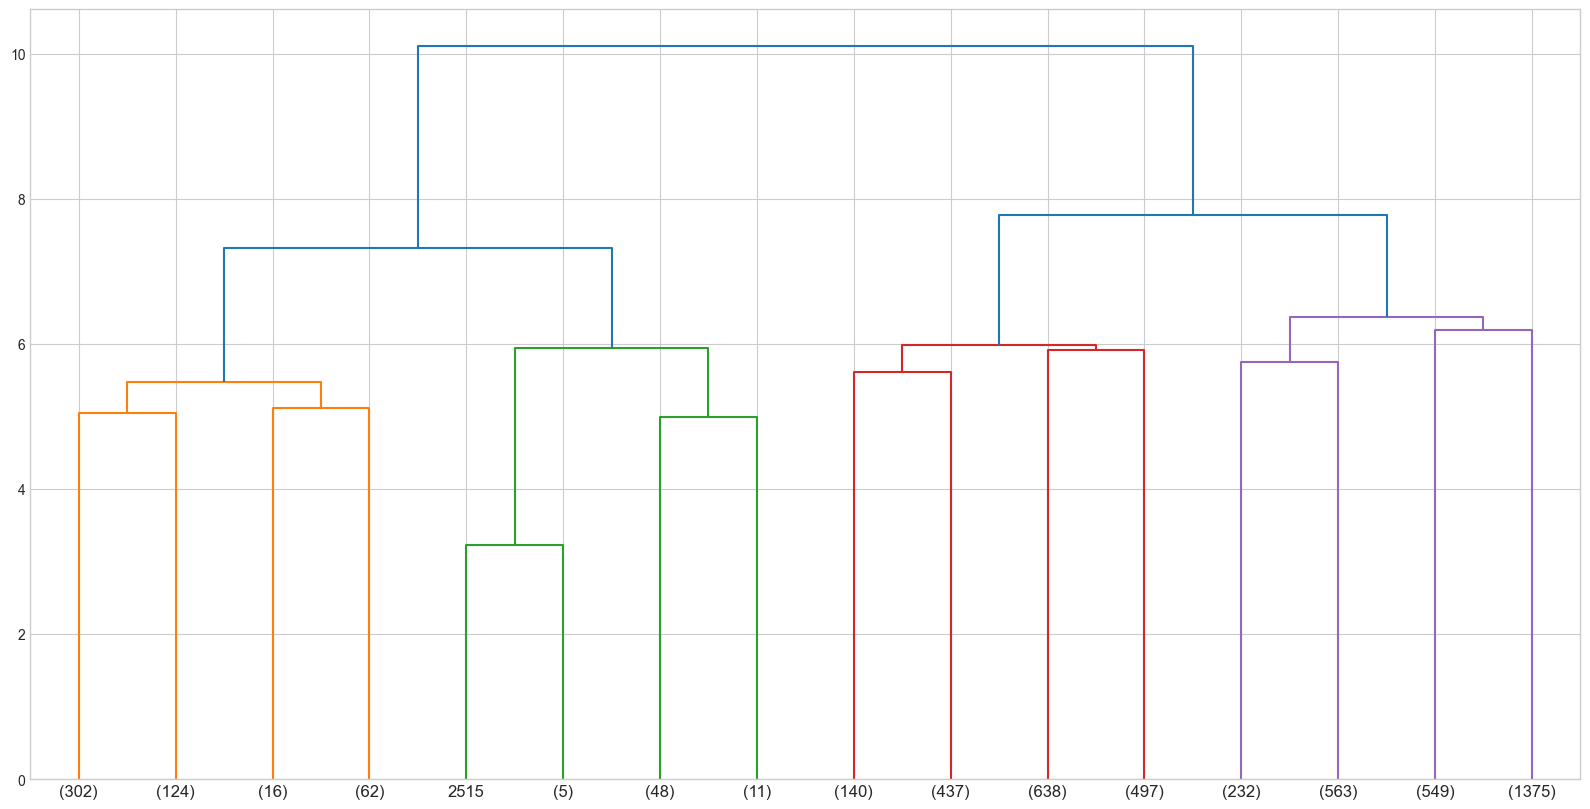

In [ ]:
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
d=dendrogram(link, p=3, truncate_mode='level')

In [20]:
dist_matrix[0].mean()

np.float64(0.7770804297061386)

In [8]:
model_hier = AgglomerativeClustering(n_clusters=4, metric='precomputed', linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3]), array([ 399, 4587,    5,    9]))


In [11]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'UMAP')

2026-05-12 17:01:44.954 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running UMAP dimensionality reduction...
2026-05-12 17:01:44.955 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-12 17:02:29.970 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assembling properties for Chemiscope...
2026-05-12 17:02:29.973 | INFO     | src.helper_funct

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


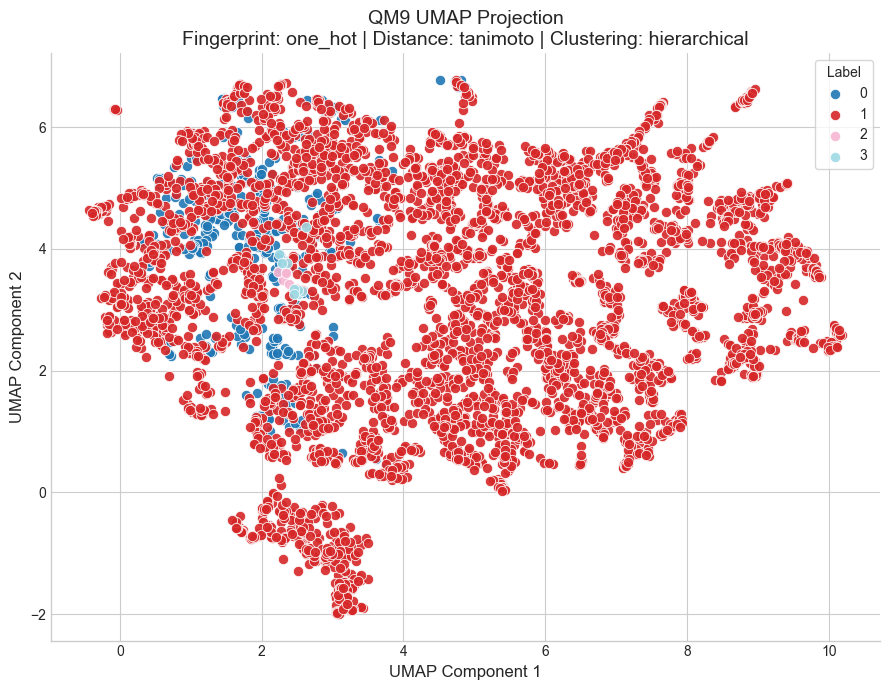

2026-05-12 17:01:20.438 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/one_hot/umap_hierarchical_projection.png


In [10]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method='UMAP',
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [ ]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

- Clustering on unique selfies string and patterns - such as unique branching and number of atoms

In [ ]:
ari_score = adjusted_rand_score(df["generic_scaffold"], df["labels_hier"])
print(f"ARI score: {ari_score} ")

ARI score: 0.014431949866576537 


In [ ]:
benchmark_functional_groups(df, "labels_hier")

[{'Cluster': 1,
  'Size': 1562,
  'Top_FG_1': 'fr_ether (36.2%)',
  'Top_FG_2': 'fr_alcohol (22.8%)',
  'Top_FG_3': 'fr_amine (18.4%)'},
 {'Cluster': 2,
  'Size': 2079,
  'Top_FG_1': 'fr_ether (49.7%)',
  'Top_FG_2': 'fr_alcohol (34.4%)',
  'Top_FG_3': 'fr_ketone (14.3%)'},
 {'Cluster': 3,
  'Size': 1089,
  'Top_FG_1': 'fr_ether (46.8%)',
  'Top_FG_2': 'fr_alcohol (33.5%)',
  'Top_FG_3': 'fr_amine (9.5%)'},
 {'Cluster': 4,
  'Size': 8,
  'Top_FG_1': 'fr_benzene (0.0%)',
  'Top_FG_2': 'fr_alcohol (0.0%)',
  'Top_FG_3': 'fr_phenol (0.0%)'},
 {'Cluster': 5,
  'Size': 262,
  'Top_FG_1': 'fr_ether (42.4%)',
  'Top_FG_2': 'fr_alcohol (9.2%)',
  'Top_FG_3': 'fr_amine (4.6%)'}]

# KMedoids

In [ ]:
model_km = KMedoids(n_clusters=2, metric="precomputed", random_state=42)
labels_km = model_km.fit_predict(dist_matrix)
medoid_indices = model_km.medoid_indices_
print(medoid_indices)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)
medoids_df = df[medoid_indices]
print(medoids_df.select(["labels_km", "mol_id", "smiles", "scaffold_smiles"]))

[3755  636]
(array([0, 1], dtype=uint64), array([2064, 2936]))
shape: (2, 4)
┌───────────┬───────────┬─────────────────────────────────┬─────────────────┐
│ labels_km ┆ mol_id    ┆ smiles                          ┆ scaffold_smiles │
│ ---       ┆ ---       ┆ ---                             ┆ ---             │
│ u64       ┆ str       ┆ str                             ┆ str             │
╞═══════════╪═══════════╪═════════════════════════════════╪═════════════════╡
│ 0         ┆ qm9_99831 ┆ [H]C([H])([H])C([H])([H])[C@@]… ┆ C1CC1           │
│ 1         ┆ qm9_14859 ┆ [H]C([H])([H])C([H])([H])C([H]… ┆ C1CC1           │
└───────────┴───────────┴─────────────────────────────────┴─────────────────┘


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-27 19:14:04.330 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:14:04.331 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:14:26.515 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:14:26.518 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:14:26.777 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:14:26.845 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


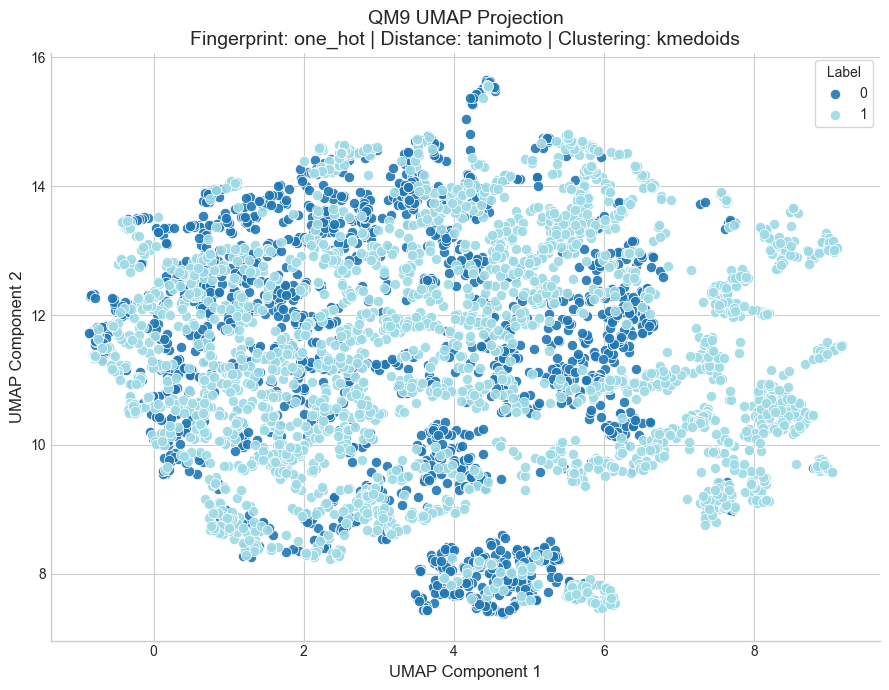

2026-05-07 20:30:17.631 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/one_hot/umap_kmedoids_projection.png


In [ ]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [ ]:
average_numeric_by_cluster(df, "labels_km")

shape: (2, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬────────┬─────────┬─────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2387,2.138039,0.0,124.343527,0.121491,30.713029,0.896445,12.846392,8.847088,1.809384,0.035191,0.004189,2.081693,20.10641,2.07245,2.709258,0.02945,0.118127,0.852423,0.976121,1.699623,7.092166,0.206116,0.778802,5.780478,6.426477,43.084625,1.259839,0.000838,0.457478,0.005027,0.099288,0.101382,0.000838,0.027231,0.11437,0.556766,0.0,2.379518,77.98814,-6.501755,0.787324,7.289008,1232.165029,4.577966,-11056.138856,-11055.898309,-11055.872595,-11057.056817,33.257322,-81.620333,-82.139562,-82.620566,-75.861621,3.158116,1.361481,1.116047,2.600754,86.803519,3.519062,9.677419,43.084625,884,"""Acyclic""",9.677419,244,"""C1CC1""",11.101801,1,null,0.0
1,2613,1.96625,0.0,121.227325,0.025258,41.960964,0.824197,12.858486,8.717949,1.515882,0.305779,0.044776,2.792576,16.652889,2.051171,1.899349,0.102138,0.328997,0.568865,0.864524,2.310754,5.936089,0.655568,1.747799,3.522005,6.289705,33.083812,1.264916,0.004975,0.242633,0.049369,0.17145,0.125144,0.002296,0.046307,0.128971,0.499809,0.002296,2.95056,72.579089,-6.570639,-0.154319,6.416319,1152.144052,3.566294,-11280.265795,-11280.043277,-11280.017581,-11281.168181,30.147739,-70.887549,-71.298491,-71.695216,-66.068029,240.938633,1.429022,1.11754,1.577114,60.084194,29.161883,10.753923,33.083812,929,"""Acyclic""",10.753923,220,"""C1CCCC1""",18.40796,1,null,0.0


In [ ]:
benchmark_functional_groups(df, "labels_km")

[{'Cluster': 0,
  'Size': 2387,
  'Top_FG_1': 'fr_ether (47.8%)',
  'Top_FG_2': 'fr_alcohol (38.8%)',
  'Top_FG_3': 'fr_ketone (11.0%)'},
 {'Cluster': 1,
  'Size': 2613,
  'Top_FG_1': 'fr_ether (41.3%)',
  'Top_FG_2': 'fr_alcohol (20.5%)',
  'Top_FG_3': 'fr_amine (15.6%)'}]

# Spectral

In [ ]:
gaussian_kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
affinity_matrix = 1 - dist_matrix

model_spectral = SpectralClustering(
                n_clusters=2,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(affinity_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
# print(np.unique(labels_spectral, return_counts=True))

In [ ]:
# create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


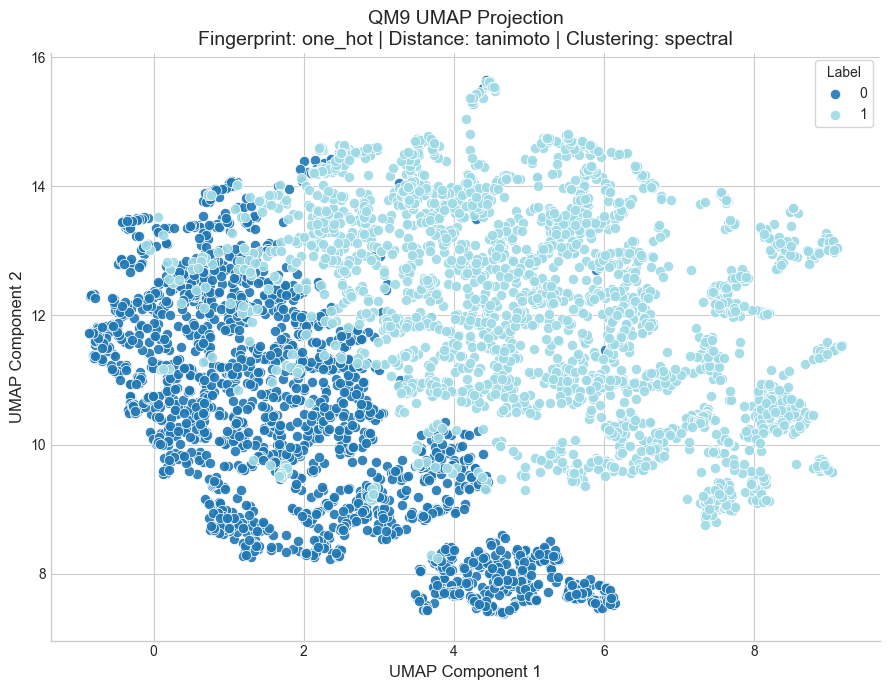

2026-05-07 20:31:24.908 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/one_hot/umap_spectral_projection.png


{'coords': array([[ 7.383565 , 11.246834 ],
        [ 7.3954296, 11.310536 ],
        [ 7.453358 , 11.010421 ],
        ...,
        [ 1.4909331, 12.994177 ],
        [ 1.3960736, 12.986557 ],
        [ 2.179153 , 13.418532 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/umap_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'spectral'}

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4998,0.762312,0.0,122.702481,0.066427,36.327931,0.857554,12.852974,8.779512,1.668667,0.178071,0.023409,2.452581,18.306122,2.062847,2.281713,0.065693,0.230267,0.70404,0.916166,2.010404,6.505602,0.431373,1.295718,4.59984,6.358143,13.668267,1.262684,0.003802,0.345338,0.030812,0.130052,0.12405,0.001601,0.036014,0.119648,0.527611,0.001,2.687,75.170944,-6.520838,0.306178,6.827039,1188.863837,4.055458,-11169.362753,-11169.131892,-11169.106202,-11170.27236,31.61216,-76.051295,-76.514865,-76.952263,-70.778261,3.452072,1.405258,1.120171,3.330532,0.587435,72.388956,17.046819,10.564226,13.668267,1533,"""Acyclic""",10.564226,324,"""C1CCCC1""",12.705082,1,null,0.0
1,1,0.928571,0.0,127.0,0.0,92.0,0.538691,13.133702,9.0,1.0,1.0,0.0,5.0,14.0,2.0,3.0,0.0,1.0,0.0,3.0,5.0,5.0,0.0,4.0,0.0,6.0,13.0,1.258894,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.6518,68.849998,-5.888544,-0.45443,5.434114,1033.511719,2.785031,-12790.313477,-12790.105469,-12790.079102,-12791.176758,29.983,-61.665958,-61.996605,-62.330681,-57.45475,2.42075,1.87923,1.05879,4.0,0.0,0.0,100.0,0.0,13.0,1,"""c1ccnnc1""",100.0,1,"""C1CCCCC1""",100.0,1,null,0.0
2,1,0.928571,0.0,127.0,0.0,92.0,0.538691,13.133702,9.0,1.0,1.0,0.0,5.0,14.0,2.0,3.0,0.0,1.0,0.0,3.0,5.0,5.0,0.0,4.0,0.0,6.0,13.0,1.258894,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.6518,68.849998,-5.888544,-0.45443,5.434114,1033.511719,2.785031,-12790.313477,-12790.105469,-12790.079102,-12791.176758,29.983,-61.665958,-61.996605,-62.330681,-57.45475,2.42075,1.87923,1.05879,4.0,0.0,0.0,100.0,0.0,13.0,1,"""c1ccnnc1""",100.0,1,"""C1CCCCC1""",100.0,1,null,0.0


# DBSCAN 

In [ ]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=4,
    metric='precomputed'
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([ 382, 4569,    4,    6,    6,    5,    9,    4,    4,    3,    4,
          4]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-04-27 19:14:29.364 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:14:29.365 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:14:51.584 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:14:51.587 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:14:52.295 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:14:52.366 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

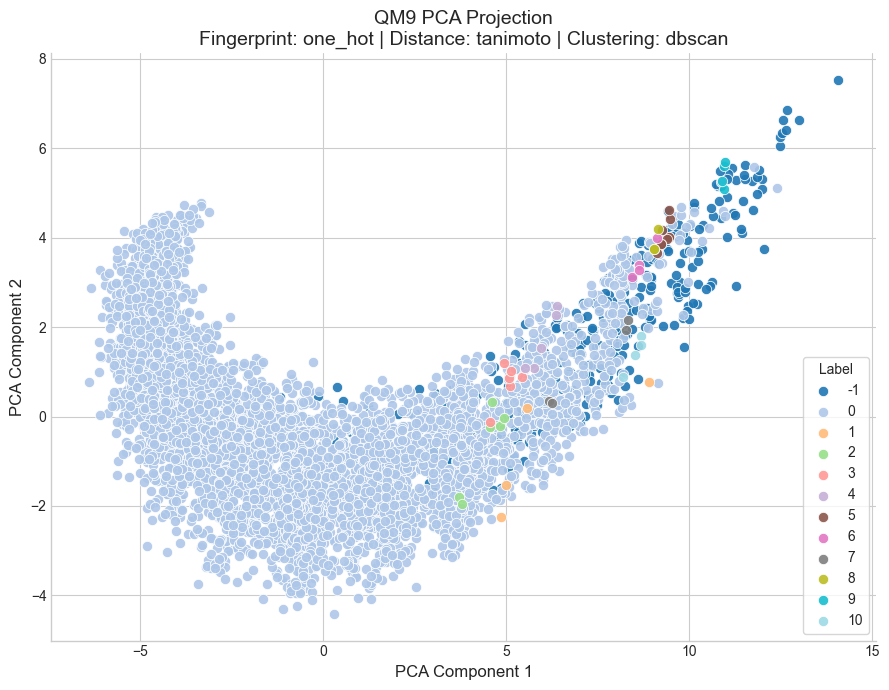

2026-04-27 19:14:53.078 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png


{'coords': array([[-5.60745462,  1.4015037 ],
        [-5.61246276,  3.38903767],
        [-5.05969243,  2.23594487],
        ...,
        [-1.62225685, -1.64970579],
        [-5.76115234,  0.23034785],
        [-4.67063778, -2.31152602]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'dbscan'}

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [ ]:
average_numeric_by_cluster(df, "labels_db")

shape: (12, 73)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,382,2.228006,0.0,125.094241,0.544503,19.641361,0.88701,12.831939,8.950262,2.099476,0.020942,0.0,1.421466,22.232984,2.094127,3.010471,0.015603,0.053169,0.931228,0.842932,1.02356,7.973822,0.117801,0.39267,7.018325,6.486911,49.54712,1.257858,0.0,0.277487,0.0,0.133508,0.02356,0.0,0.002618,0.036649,0.405759,0.0,1.642651,83.604424,-6.469172,1.446941,7.91602,1293.94159,5.185045,-10563.08615,-10562.837004,-10562.811337,-10564.010354,35.054034,-88.596388,-89.182958,-89.714601,-82.269507,3.035653,1.311201,1.104815,3.554974,0.230366,87.958115,2.094241,9.947644,49.54712,224,"""Acyclic""",9.947644,96,"""Acyclic""",9.947644,1,null,0.0
0,4569,2.031291,0.0,122.488947,0.027358,38.248632,0.855969,12.854654,8.763406,1.613263,0.191508,0.027796,2.551762,17.926242,2.058239,2.214927,0.072274,0.245133,0.682592,0.925367,2.11578,6.346684,0.471,1.371635,4.369009,6.340775,36.74524,1.262957,0.003283,0.352594,0.03086,0.137448,0.121909,0.001751,0.04049,0.130225,0.538411,0.001313,2.778116,74.352729,-6.545785,0.185239,6.730992,1180.575846,3.941848,-11231.681688,-11231.452295,-11231.426587,-11232.590134,31.30667,-74.820341,-75.271274,-75.699271,-69.652673,139.158748,1.404236,1.117983,1.922521,0.549792,71.459838,18.340994,10.199168,36.74524,1418,"""Acyclic""",10.199168,302,"""C1CCCC1""",13.832348,1,null,0.0
1,4,2.142273,0.0,124.75,0.5,29.0,0.931501,12.96887,8.5,0.0,0.0,0.0,2.25,22.75,1.911818,6.75,0.0,0.041667,0.958333,0.75,2.0,6.5,0.0,0.25,6.0,8.0,48.75,1.223936,0.0,0.75,0.0,0.0,0.25,0.0,0.0,0.0,1.0,0.0,2.13915,80.055,-6.729375,2.016364,8.74642,1698.422455,5.535272,-11175.989502,-11175.688477,-11175.663086,-11177.004883,38.364,-88.81012,-89.385706,-89.944799,-82.304497,3.516308,0.835507,0.710355,3.0,0.25,0.0,0.0,100.0,48.75,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
2,6,2.059289,0.0,127.0,0.833333,20.0,0.925915,12.841175,9.0,0.333333,0.0,0.0,1.5,22.666667,1.942029,4.833333,0.166667,0.047619,0.785714,0.833333,1.5,6.5,1.333333,0.333333,5.833333,7.5,46.666667,1.231075,0.0,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.9166,86.969999,-6.762483,0.956934,7.71987,1615.572286,5.210191,-10868.447917,-10868.158203,-10868.132487,-10869.433594,38.906,-89.356634,-89.914628,-90.454413,-82.994333,3.10335,0.971833,0.779792,3.0,0.333333,33.333333,0.0,66.666667,46.666667,3,"""Acyclic""",66.666667,2,"""Acyclic""",66.666667,1,null,0.0
3,6,2.248413,0.0,124.5,-0.166667,17.5,0.896019,12.786814,9.0,3.166667,0.0,0.0,1.5,20.833333,2.20873,1.666667,0.0,0.0,1.0,1.333333,0.833333,8.166667,0.0,0.0,7.5,5.833333,46.833333,1.278181,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,1.737183,79.531667,-6.003739,1.612728,7.616467,999.61673,4.673977,-10649.382487,-10649.168783,-10649.142904,-10650.246582,32.0065,-83.287167,-83.844112,-84.332466,-77.382057,2.475248,1.849822,1.481462,3.0,0.5,100.0,0.0,0.0,46.833333,6,"""C1C[NH+]2CC3C1C32""",16.666

# HDBSCAN

In [ ]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=300, ms=1, clusters=2, noise=0.15, persistence=0.062, score=0.052
mcs=120, ms=1, clusters=3, noise=0.10, persistence=0.041, score=0.037
mcs=150, ms=1, clusters=3, noise=0.10, persistence=0.041, score=0.037
mcs=220, ms=1, clusters=3, noise=0.10, persistence=0.041, score=0.037
mcs=300, ms=10, clusters=2, noise=0.13, persistence=0.037, score=0.032
mcs=220, ms=40, clusters=2, noise=0.08, persistence=0.031, score=0.029
mcs=300, ms=40, clusters=2, noise=0.08, persistence=0.031, score=0.029
mcs=80, ms=1, clusters=4, noise=0.09, persistence=0.031, score=0.028
mcs=300, ms=30, clusters=2, noise=0.14, persistence=0.033, score=0.028
mcs=220, ms=55, clusters=2, noise=0.11, persistence=0.031, score=0.027
mcs=300, ms=75, clusters=2, noise=0.13, persistence=0.030, score=0.026
mcs=10, ms=1, clusters=45, noise=0.04, persistence=0.027, score=0.026
mcs=10, ms=1, clusters=45, noise=0.04, persistence=0.027, score=0.026
mcs=300, ms=150, clusters=2, noise=0.10, persistence=0.028, sco

In [ ]:
hdbscan = HDBSCAN(min_cluster_size=220, min_samples=40, metric='precomputed')
labels_hdbscan = hdbscan.fit_predict(dist_matrix.astype(np.float64))
df= df.with_columns(labels_hdbscan=labels_hdbscan)
print(np.unique(labels_hdbscan, return_counts=True))

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([-1,  0,  1]), array([ 413, 4283,  304]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-05 15:04:18.896 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-05 15:04:18.912 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-05 15:05:12.598 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-05 15:05:12.657 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-05 15:05:12.923 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-05 15:05:13.011 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (3, 74)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,413,0.938297,0.0,123.709443,-0.35109,29.530266,0.890738,12.789892,8.937046,3.336562,0.016949,0.021792,2.125908,18.561743,2.217593,1.447942,0.019909,0.079086,0.901005,1.1477,1.595642,7.397094,0.130751,0.489104,6.191283,5.823245,17.184019,1.282195,0.0,0.46247,0.0,0.070218,0.089588,0.004843,0.024213,0.104116,0.520581,0.0,2.38321,74.7277,-6.349872,0.991786,7.341731,1014.327251,4.070615,-11090.759767,-11090.5532,-11090.527489,-11091.627383,30.124351,-76.409648,-76.900088,-77.339198,-71.062584,3.096747,1.667339,1.387413,1.213075,0.559322,0.0,97.094431,1.694915,1.210654,17.184019,304,"""C1C2CC3C1C23""",1.937046,159,"""C1C2CC3C1C23""",7.021792,1,null,0.0
0,4283,0.739727,0.0,122.386878,0.119075,37.085454,0.85339,12.858741,8.748774,1.455755,0.200093,0.021714,2.489377,18.224842,2.043209,2.367966,0.072796,0.251606,0.675598,0.879524,2.062806,6.378473,0.477936,1.412328,4.369134,6.422367,13.178847,1.260149,0.004436,0.32127,0.036423,0.135653,0.129115,0.001401,0.038524,0.12141,0.53117,0.0007,2.725132,75.128317,-6.540459,0.216334,6.756804,1210.218871,4.042029,-11162.668021,-11162.434625,-11162.408937,-11163.58264,31.71059,-75.858999,-76.317998,-76.754039,-70.60908,3.521123,1.376638,1.089493,3.617324,0.59421,0.0007,68.830259,19.145459,12.024282,13.178847,1245,"""Acyclic""",12.024282,230,"""C1CCCC1""",14.545879,1,null,0.0
1,304,0.842531,0.0,125.809211,-0.108553,35.256579,0.869044,12.859264,9.0,2.398026,0.092105,0.049342,2.394737,19.075658,2.128884,2.203947,0.027393,0.140079,0.832528,1.131579,1.855263,7.075658,0.180921,0.766447,5.657895,6.177632,15.782895,1.271867,0.0,0.523026,0.006579,0.138158,0.098684,0.0,0.016447,0.115132,0.483553,0.006579,2.568836,76.332105,-6.472506,0.635538,7.108169,1124.091785,4.215706,-11381.134046,-11380.906028,-11380.880342,-11382.029776,32.235937,-78.179025,-78.669629,-79.123137,-72.687896,2.95517,1.455547,1.188917,2.171053,0.526316,0.0,88.486842,8.881579,2.631579,15.782895,205,"""C1CC2CC12""",2.960526,85,"""C1CC2CC12""",10.197368,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


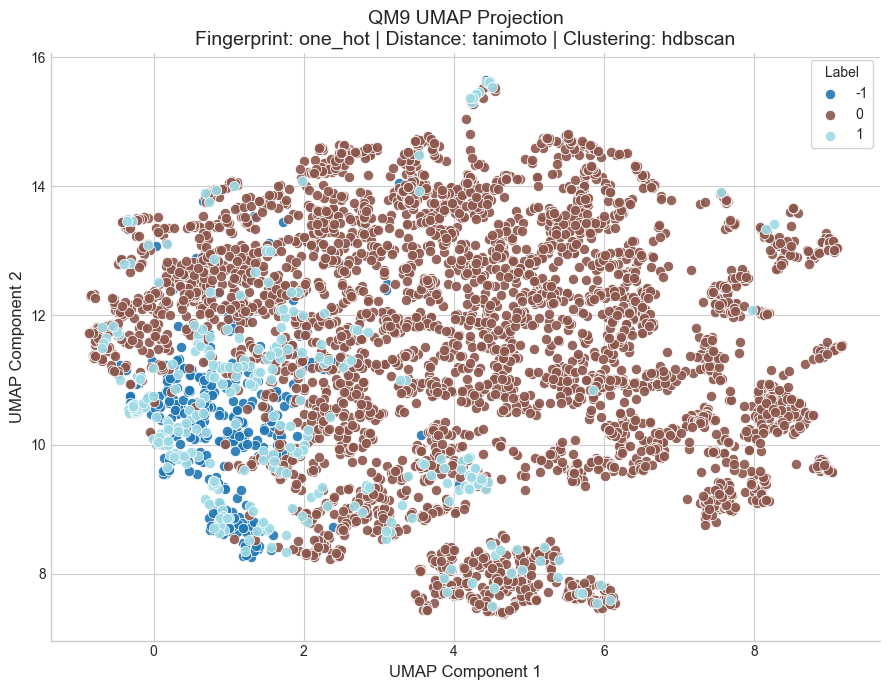

2026-05-07 20:32:59.286 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/one_hot/umap_hdbscan_projection.png


In [ ]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

# KMeans

In [ ]:
kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df= df.with_columns(kmeans_labels=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1313, 1636, 2051]))


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-04-27 19:15:53.936 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:15:53.940 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:16:18.530 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:16:18.535 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:16:18.779 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:16:18.849 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, "kmeans_labels")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

kmeans_labels,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1313,2.201195,0.0,125.137091,0.431835,20.774562,0.906078,12.834557,8.916222,1.910129,0.006093,0.002285,1.560548,21.866717,2.07482,2.990099,0.015379,0.063529,0.921092,0.75933,1.190404,7.687738,0.118812,0.470678,6.766184,6.543031,48.136329,1.256628,0.0,0.313785,0.0,0.086824,0.040366,0.000762,0.012947,0.067784,0.522468,0.0,1.921745,82.270983,-6.468248,1.275768,7.743989,1292.199536,5.098946,-10727.329149,-10727.080055,-10727.054351,-10728.254951,34.746459,-87.557876,-88.133374,-88.657613,-81.318425,3.021545,1.310129,1.088399,3.367098,0.161462,-0.055598,3.588728,89.946687,0.609292,9.444021,48.136329,505,"""Acyclic""",9.444021,176,"""C1CC1""",11.271896,1,null,0.0
1,1636,1.873772,0.0,119.778117,-0.066626,49.858802,0.784489,12.890527,8.613081,1.271394,0.452323,0.070905,3.253667,15.05868,2.02978,1.757335,0.122834,0.440265,0.436901,0.953545,2.724328,5.355746,0.748778,2.222494,2.388142,6.233496,28.349022,1.265255,0.006112,0.251222,0.075795,0.209046,0.146699,0.002445,0.060513,0.130196,0.4511,0.003667,3.227093,69.429688,-6.609657,-0.559385,6.050262,1119.599525,3.10993,-11458.634945,-11458.418377,-11458.392678,-11459.532185,28.90171,-65.592859,-65.952203,-66.310536,-61.206442,382.915514,1.462901,1.114148,1.090465,0.937042,0.0,7.0,44.132029,43.031785,12.836186,28.349022,559,"""Acyclic""",12.836186,119,"""C1CCCC1""",23.349633,1,null,0.0
2,2051,2.089541,0.0,123.50707,-0.049732,36.133593,0.887536,12.834172,8.824963,1.800098,0.065822,0.003901,2.386153,18.606046,2.07786,2.256948,0.056573,0.164775,0.778652,0.990736,1.986836,6.623111,0.401755,1.058996,4.978059,6.331546,38.863481,1.264043,0.002438,0.440273,0.008289,0.111653,0.134569,0.001463,0.03413,0.150171,0.590444,0.0,2.724012,75.181901,-6.524896,0.349185,6.874021,1181.573631,4.126557,-11231.120443,-11230.889209,-11230.863501,-11232.03007,31.816661,-76.93003,-77.402812,-77.846616,-71.580995,3.263775,1.399505,1.137164,2.010726,0.423208,-0.028279,6.789859,84.787908,6.533398,8.678693,38.863481,814,"""Acyclic""",8.678693,245,"""C1CC1""",9.800098,1,null,0.0
